# Determining Sensor Errors

The objective of this project is to clean the provided dataset (source: https://www.kaggle.com/datasets/rgupta12/metro-interstate-traffic-volume) to prepare the data for downstream analysis.

This will include:
 - Identifying physical sensor errors
 - Writing a function to replace the errors with a rolling mean
 - Flag values more than 3 standard deviations from the mean as `is_outlier`

In [184]:
 # import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
 # load dataset
df = pd.read_csv(r'C:\Users\ozmos\OneDrive\Desktop\Data Science\Manufacturing Data Specialist\Metro Interstate Project\Metro Interstate Data\Metro_Interstate_Traffic_Volume.csv')
raw_data = df.copy()  # keep a copy of the original data for reference

# display the first few rows of the dataset
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [186]:
# next we'll get a general overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [187]:
'data shape:', df.shape

('data shape:', (48204, 9))

In [188]:
 # check for missing values
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

The dataset does not appear to have any missing values aside from those missing from the 'holiday' column. Whether or not a specific day was a holiday is irrelevant to our purposes as we are specifically focusing on the 'temp' column.

Note: on a large enough dataset, I would consider dropping columns such as 'holiday" to reduce memory needs.

In [189]:
# we're looking for temperature outliers, so we'll filter the dataset for rows where the temperature is 0
temp_outliers = df[df['temp'] == 0]
temp_outliers

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670


In [190]:
# show sum of records where 'temp' is 0
absolute_zero_sum = temp_outliers['temp'].count()
print (f'Number of records where temperature is 0: {absolute_zero_sum}')


Number of records where temperature is 0: 10


Data Audit Summary: Temperature Sensor Integrity

Objective: Validate physical accuracy of "Production Temperature" (using the 'temp' column as a proxy) before performing downstream calculations.

Key Findings:
 - Total Sensor Failures: 10 instances of "dead" readings identified and isolated
 - Failure Signature: Readings of 0.00 Kelvin (-273.15∘C)
 - Criticality: High. Absolute zero is a physical impossibility in this environment. These represent electrical or hardware failures, not true temperature drops.

Technical Mitigation Strategy:
 - Convert all 0.0 values in 'temp' column to NaN
 - Apply a 3-hour rolling mean to "reconstruct" missing values based on adjacent historical data.

In [191]:
def clean_sensor_data(df, window_size=3):
    """
    Cleans temperature sensor data by replacing physical errors with a rolling mean and flagging statistical outliers.
    """
    # 1. Identify physical errors (0 Kelvin):
    df['temp'] = df['temp'].replace(0, np.nan)

    # 2. Impute using centered rolling mean:
    df['temp_rolling_mean'] = df['temp'].rolling(window=window_size, min_periods=1, center=True).mean()
    df['temp'] = df['temp'].fillna(df['temp_rolling_mean'])

    # 3. Catch any remaining NaN values with forward fill:
    df['temp'] = df['temp'].ffill()

    # 4. Determine mean and standard deviation:
    mean, std = df['temp'].mean(), df['temp'].std()

    # 5. Flag outliers (beyond 3 standard deviations):
    df['is_outlier'] = ((df['temp'] < mean - 3 * std) | (df['temp'] > mean + 3 * std))

    #6 Clean up temporary column
    df.drop(columns=['temp_rolling_mean'], inplace=True)

    return df


In [192]:
cleaned_df = clean_sensor_data(df, window_size=3)
cleaned_df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_outlier
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,False
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,False
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,False
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,False
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,False


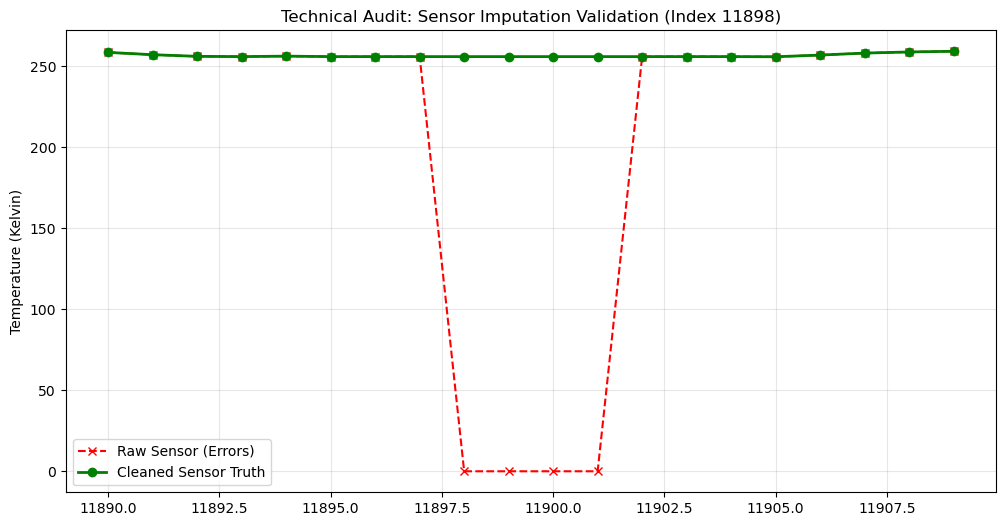

In [193]:
# this cell was generated by GeminiAI

# Define the 'Zoom' window for the sensor failure at index 11898
start, end = 11890, 11910

plt.figure(figsize=(12, 6))

# 1. Plot the snapshot of the original errors
plt.plot(raw_data['temp'].iloc[start:end], 
         label='Raw Sensor (Errors)', 
         color='red', linestyle='--', marker='x')

# 2. Plot your cleaned 'Sensor Truth'
plt.plot(cleaned_df['temp'].iloc[start:end], 
         label='Cleaned Sensor Truth', 
         color='green', linewidth=2, marker='o')

plt.title('Technical Audit: Sensor Imputation Validation (Index 11898)')
plt.ylabel('Temperature (Kelvin)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [194]:
# final check for any remaining 0 values in the 'temp' column
print(f'Physical error (0K) values: {(cleaned_df['temp'] ==0).sum()}')
print(f'Remaining NaN values: {cleaned_df['temp'].isna().sum()}')
print(f'Outliers flagged: {cleaned_df['is_outlier'].sum()}')

Physical error (0K) values: 0
Remaining NaN values: 0
Outliers flagged: 0


In [195]:
# 1. Check the actual counts of True vs False
print(df['is_outlier'].value_counts())

# 2. Calculate the 'Red Zone' boundaries manually to see what the 'True' threshold is
mean_temp = df['temp'].mean()
std_temp = df['temp'].std()
upper_limit = mean_temp + (3 * std_temp)
lower_limit = mean_temp - (3 * std_temp)

print(f"Any value above {upper_limit} or below {lower_limit} should be True.")

is_outlier
False    48204
Name: count, dtype: int64
Any value above 319.399803300359 or below 243.11799447575916 should be True.


Objective Summary:

The Problem: Sensor issues caused 10 "dead" readings of 0 degrees Kelvin, skewing the Jan averages by ~0.5% and the Feb averages by ~0.9%.

Action Taken: Generated a rolling 3-hour average of the 'temp' column and imputed the resulting value in the 0/NaN values. As an additional net, a forward fill was used to impute any values that could not be filled with the rolling mean.

Result: Established a "sensor truth" that allows us to utilize the records with "dead" readings as part of our data. Additionally, we flagged any and all readings that are outliers (in this instance, readings more than 3 standard deviations outside the mean).

Additional note: the function generated can be used going forward with the next batch of data in order to acheive similar results.